In [1]:
import numpy as np
import matplotlib.pyplot as plt 
from matplotlib.gridspec import GridSpec
from scipy.stats import gaussian_kde
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm

In [2]:
# ================================================================
# Detect the start and end of activity cycles (bursts)
# ================================================================
#
# This function identifies periods of elevated network activity
# (activity cycles) in the time series rho(t).
#
# The minimum value of rho is used as a baseline ("threshold").
# A time point is considered part of a burst when its activity
# exceeds this baseline by more than the specified precision.
#
# Parameters
# ----------
# Rho : array-like
#     Time series of the fraction of active neurons, rho(t).
#
# precision : float
#     Tolerance above the minimum activity used to distinguish
#     active periods from silent periods.
#
# Returns
# -------
# startlocs : list
#     Time indices corresponding to the beginning of each
#     detected activity cycle.
#
# endlocs : list
#     Time indices corresponding to the end of each
#     detected activity cycle.
#
# Notes
# -----
# The function scans the activity time series and identifies a
# cycle when rho rises above the baseline threshold. The start
# point is shifted one time step backward when the activity is
# already increasing at the detected crossing.
#
# The final 10 time steps are excluded from the search to avoid
# detecting an incomplete cycle at the end of the simulation.
# ================================================================

def StartAndEndPoints(Rho, precision):

    # Time indices corresponding to the activity time series.
    t = np.arange(0, len(Rho))
    tmax = max(t)

    # Use the minimum observed activity as the baseline.
    threshold = min(Rho)

    # Flag indicating whether the algorithm is currently
    # inside an activity cycle.
    flag = False

    # Current position in the time series.
    i = 0

    # Lists containing the detected start and end times
    # of activity cycles.
    startlocs = []
    endlocs = []

    # Scan the time series, excluding the last 10 time steps.
    while i < (tmax - 10):

        # If the activity is still within 'precision' of the
        # baseline, no activity cycle has started yet.
        if Rho[i] - threshold <= precision:
            i = i + 1
            continue

        # The activity has risen above the baseline:
        # mark this point as the tentative beginning of a cycle.
        first = i

        # If the activity was already increasing between the
        # previous and current time step, move the start point
        # one step backward.
        if Rho[i - 1] < Rho[i]:
            first = first - 1

            # Preserve the original boundary condition for i = 0.
            if i == 0:
                first = 0

        # Store the detected start time.
        startlocs.append(first)

        # We are now inside an activity cycle.
        flag = True

        # Continue until the activity returns to the baseline
        # (within the specified precision).
        while flag and i < tmax - 1:

            i = i + 1

            # Once the activity falls back to the baseline region,
            # the current activity cycle is considered finished.
            if Rho[i] - threshold <= precision:
                flag = False

        # Store the detected end time.
        endlocs.append(i)

        # Move to the next time point before searching for
        # another activity cycle.
        i = i + 1

    return startlocs, endlocs

In [3]:
# ================================================================
# Calculate the duration of detected activity bursts
# ================================================================
#
# This function identifies activity cycles in rho(t) using
# StartAndEndPoints() and groups nearby activity cycles into
# individual bursts.
#
# Parameters
# ----------
# Rho : array-like
#     Time series of the fraction of active neurons, rho(t).
#
# precision : float
#     Tolerance used by StartAndEndPoints() to distinguish
#     active periods from the baseline/silent state.
#
# Returns
# -------
# y_new : ndarray
#     Binary time series indicating burst activity:
#
#         1 -> time point belongs to a detected burst
#         0 -> time point is outside a detected burst
#
# Notes
# -----
# Two consecutive activity cycles are considered part of the
# same burst when the silent interval between them is shorter
# than smean.
#
# Internally, the duration of each detected burst is assigned
# to all of its time points. This representation is subsequently
# converted into a binary burst indicator.
# ================================================================

def BurstWidth(Rho, precision):

    # Length of the activity time series.
    tmax = len(Rho)

    # Store the duration of the burst associated with each
    # time point. Zero indicates that the point is not part
    # of a detected burst.
    y = np.zeros(tmax)

    # Binary output array.
    #
    # Initialize it here so that it is also defined in the
    # special case where the activity starts near t = 0.
    y_new = np.zeros(tmax)

    # Detect the start and end points of individual activity cycles.
    startlocs, endlocs = StartAndEndPoints(Rho, precision)

    # If no activity cycles are detected, return an array of zeros.
    if len(startlocs) == 0:
        return y_new

    # ------------------------------------------------------------
    # Group consecutive activity cycles into bursts.
    # ------------------------------------------------------------

    # Minimum silent interval required to separate two bursts.
    smean = 10

    # Start time of the current burst.
    a = startlocs[0]

    # Examine consecutive activity cycles.
    i = 0

    while i < len(endlocs):

        # If this is the last detected cycle, it defines the end
        # of the current burst.
        if i == len(endlocs) - 1:
            b = endlocs[i]

            # Duration of the current burst.
            burst_duration = b - a

            # Assign the burst duration to all time points
            # belonging to this burst.
            for j in np.arange(a, b):
                y[j] = burst_duration

            break

        # Check the silent interval before the next activity cycle.
        silent_interval = startlocs[i + 1] - endlocs[i]

        if silent_interval < smean:

            # The next activity cycle is close enough to the
            # current one to be considered part of the same burst.
            i += 1
            continue

        # The silent interval is long enough to separate the
        # current burst from the next one.
        b = endlocs[i]

        # Duration of the current burst.
        burst_duration = b - a

        # Assign the burst duration to all time points in the burst.
        for j in np.arange(a, b):
            y[j] = burst_duration

        # The next activity cycle starts a new burst.
        a = startlocs[i + 1]

        i += 1

    # ------------------------------------------------------------
    # Handle activity beginning very close to t = 0.
    # ------------------------------------------------------------

    if a < 10:

        # If the entire time series remains at a very low activity
        # level, classify it as having no detectable burst activity.
        if all(v < 0.01 for v in Rho):
            return y_new

        # Otherwise, classify the time series as continuously active.
        y_new[:] = 1

        # Exclude the first and last time points.
        y_new[0] = 0
        y_new[-1] = 0

        return y_new

    # ------------------------------------------------------------
    # Convert burst-duration representation into a binary indicator.
    # ------------------------------------------------------------

    # Any time point with a non-zero burst duration is marked as
    # belonging to a burst.
    y_new[y != 0] = 1

    return y_new

In [4]:
# ================================================================
# Extract burst onset times
# ================================================================
#
# This function converts the activity time series rho(t) into a
# binary burst signal and identifies the onset time of each burst.
#
# Parameters
# ----------
# rho : array-like
#     Time series of the fraction of active neurons, rho(t).
#
# precision : float
#     Tolerance used by BurstWidth() and StartAndEndPoints()
#     to identify activity cycles.
#
# Returns
# -------
# burst_onsets : ndarray
#     Time indices at which a burst begins.
#
# Notes
# -----
# A burst onset is defined as a transition in the binary burst
# signal from:
#
#     0 -> 1
#
# Therefore, the returned time corresponds to the first time
# point at which the burst signal becomes active.
# ================================================================

def get_burst_onsets(rho, precision):

    # Convert rho(t) into a binary burst-activity signal.
    #
    #     0 -> outside a burst
    #     1 -> inside a burst
    burst = BurstWidth(rho, precision)

    # Detect transitions from 0 to 1.
    #
    # burst[:-1] contains the signal at times 0 ... tmax-2
    # burst[1:]  contains the signal at times 1 ... tmax-1
    #
    # Adding 1 converts the index of the preceding zero into
    # the actual time index at which the burst starts.
    burst_onsets = np.where(
        (burst[:-1] == 0) & (burst[1:] == 1)
    )[0] + 1

    return burst_onsets

In [5]:
# ================================================================
# Assign the first burst onset to each theta cycle
# ================================================================
#
# This function assigns at most one burst onset to each theta
# cycle. The assigned onset is the earliest burst onset occurring
# within the cycle.
#
# If a cycle contains no burst onset, a short lookback window
# immediately preceding the cycle is inspected. This allows a
# burst that starts just before a cycle boundary to be associated
# with the following theta cycle.
#
# Parameters
# ----------
# burst_onsets : array-like
#     Time indices of detected burst onsets.
#
# n_cycles : int
#     Number of theta cycles to analyze.
#
# T_theta : int, default=200
#     Duration of one theta cycle in simulation time steps (ms).
#
# lookback : int, default=25
#     Length of the time window immediately preceding a theta cycle
#     that is inspected when no burst onset occurs inside that
#     cycle.
#
# Returns
# -------
# first_bursts : ndarray
#     Array of length n_cycles.
#
#     Each element contains the time of the burst onset assigned
#     to that theta cycle. If no onset can be assigned, the value
#     is np.nan.
#
# Assignment rules
# ---------------
# 1. If one or more burst onsets occur within a theta cycle,
#    assign the earliest onset.
#
# 2. If no onset occurs within the cycle, inspect the preceding
#    `lookback` time steps.
#
# 3. If the latest onset in the lookback window is the same onset
#    that was already assigned to the previous cycle, do not
#    assign it again.
#
# 4. If the onset is a distinct, later onset, assign it to the
#    current cycle.
#
# This procedure prevents a single burst onset near a theta-cycle
# boundary from being counted in two consecutive cycles.
# ================================================================

def assign_first_bursts_to_cycles(
        burst_onsets,
        n_cycles,
        T_theta=200,
        lookback=25):

    # Initialize the output array.
    #
    # np.nan indicates that no burst onset could be assigned
    # to the corresponding theta cycle.
    first_bursts = np.full(n_cycles, np.nan)

    # Keep track of the burst onset assigned to the previous
    # theta cycle. This is used to prevent the same onset from
    # being assigned to two consecutive cycles.
    previous_assigned_onset = None

    # ------------------------------------------------------------
    # Process each theta cycle independently.
    # ------------------------------------------------------------

    for cycle in range(n_cycles):

        # Start and end times of the current theta cycle.
        #
        # Cycle 0:       [0, T_theta)
        # Cycle 1:       [T_theta, 2*T_theta)
        # etc.
        cycle_start = cycle * T_theta
        cycle_end = min(
            (cycle + 1) * T_theta,
            n_cycles * T_theta
        )

        # ========================================================
        # 1. Search for burst onsets inside the current cycle
        # ========================================================

        onsets_in_cycle = burst_onsets[
            (burst_onsets >= cycle_start) &
            (burst_onsets < cycle_end)
        ]

        if len(onsets_in_cycle) > 0:

            # If several bursts occur within the cycle, assign
            # the earliest one.
            first_onset = onsets_in_cycle[0]

            first_bursts[cycle] = first_onset

            # Remember this onset when processing the next cycle.
            previous_assigned_onset = first_onset

        # ========================================================
        # 2. No onset inside the current cycle:
        #    inspect the preceding lookback window
        # ========================================================

        else:

            # Beginning of the lookback window.
            #
            # max(0, ...) prevents the window from extending
            # before the beginning of the time series.
            lookback_start = max(
                0,
                cycle_start - lookback
            )

            # Find burst onsets occurring within the lookback
            # window but before the current theta cycle.
            previous_onsets = burst_onsets[
                (burst_onsets >= lookback_start) &
                (burst_onsets < cycle_start)
            ]

            if len(previous_onsets) > 0:

                # Use the latest onset in the lookback window.
                candidate = previous_onsets[-1]

                # ------------------------------------------------
                # Prevent double counting across cycle boundaries.
                # ------------------------------------------------
                #
                # If this onset was already assigned to the
                # previous cycle, it must not be assigned again.
                #
                # Otherwise, it represents a distinct later burst
                # and can be associated with the current cycle.
                if (previous_assigned_onset is None or
                        candidate != previous_assigned_onset):

                    first_bursts[cycle] = candidate

                    # Update the onset assigned to the previous
                    # cycle for subsequent comparisons.
                    previous_assigned_onset = candidate

                else:

                    # The candidate is the same onset that was
                    # already assigned to the previous cycle.
                    # Leave this cycle unassigned.
                    first_bursts[cycle] = np.nan

            else:

                # No burst onset was found either inside the cycle
                # or within the preceding lookback window.
                first_bursts[cycle] = np.nan

    return first_bursts

In [7]:
def FirstBurstMatrixTwoTarget(
    rho_1,
    rho_2,
    rho_total,
    precision,
    T_theta=200,
    lookback=25
):
    """
    Assign the first detected burst onset in each theta cycle
    for two target modules and for the total network activity.

    Parameters
    ----------
    rho_1 : array-like
        Activity time series of target module g1.

    rho_2 : array-like
        Activity time series of target module g2.

    rho_total : array-like
        Total network activity time series.

    precision : float
        Tolerance used by the burst-detection procedure.

    T_theta : int, optional
        Theta-cycle period in simulation time steps.
        Default is 200.

    lookback : int, optional
        Number of time steps before the beginning of a theta
        cycle searched for a burst onset when no onset occurs
        inside the cycle. Default is 25.

    Returns
    -------
    result : ndarray
        Four-column matrix containing:

            column 0 : theta-cycle number
            column 1 : first burst onset in g1 (t_g1)
            column 2 : first burst onset in g2 (t_g2)
            column 3 : first burst onset in the total network (t_fb)

        Missing burst onsets are represented by np.nan.
    """

    # ==========================================================
    # Check that all activity signals have the same length
    # ==========================================================

    if not (len(rho_1) == len(rho_2) == len(rho_total)):
        raise ValueError(
            "rho_1, rho_2, and rho_total must have the same length."
        )


    # ==========================================================
    # Determine the number of theta cycles
    # ==========================================================

    n_cycles = int(
        np.ceil(len(rho_total) / T_theta)
    )


    # ==========================================================
    # Detect burst onsets independently in:
    #   - target module g1
    #   - target module g2
    #   - total network
    # ==========================================================

    burst_onsets_g1 = get_burst_onsets(
        rho_1,
        precision
    )

    burst_onsets_g2 = get_burst_onsets(
        rho_2,
        precision
    )

    burst_onsets_total = get_burst_onsets(
        rho_total,
        precision
    )


    # ==========================================================
    # Assign the first burst onset to each theta cycle
    # ==========================================================

    t_g1 = assign_first_bursts_to_cycles(
        burst_onsets_g1,
        n_cycles,
        T_theta=T_theta,
        lookback=lookback
    )

    t_g2 = assign_first_bursts_to_cycles(
        burst_onsets_g2,
        n_cycles,
        T_theta=T_theta,
        lookback=lookback
    )

    t_fb = assign_first_bursts_to_cycles(
        burst_onsets_total,
        n_cycles,
        T_theta=T_theta,
        lookback=lookback
    )


    # ==========================================================
    # Construct the output matrix
    # ==========================================================

    cycle_numbers = np.arange(n_cycles)

    result = np.column_stack([
        cycle_numbers,
        t_g1,
        t_g2,
        t_fb
    ])

    return result

In [8]:
def FirstToBurstWinner(t_g1, t_g2, tie_window=10):
    """
    Classify each theta cycle according to the first burst
    produced by the two target modules.

    Parameters
    ----------
    t_g1 : array-like
        First-burst onset time of target module g1 for each
        theta cycle. ``np.nan`` indicates no assigned burst.

    t_g2 : array-like
        First-burst onset time of target module g2 for each
        theta cycle. ``np.nan`` indicates no assigned burst.

    tie_window : float, optional
        Maximum temporal difference (ms) between the two burst
        onsets that is considered a tie. The default is 10 ms,
        approximately one gamma cycle.

    Returns
    -------
    winner : ndarray of int
        Winner assigned to each theta cycle:

        0 : neither target module responds
        1 : g1 responds first
        2 : g2 responds first
        3 : g1 and g2 respond within the tie window

    counts : ndarray of int
        Number of theta cycles in each category:
        [none, g1, g2, tie].

    fractions : ndarray of float
        Fraction of all theta cycles in each category:
        [none, g1, g2, tie].
    """

    t_g1 = np.asarray(t_g1)
    t_g2 = np.asarray(t_g2)

    if len(t_g1) != len(t_g2):
        raise ValueError("t_g1 and t_g2 must have the same length.")

    # Initialize all cycles as "none".
    winner = np.zeros(len(t_g1), dtype=int)

    # Identify cycles in which each target module has a valid burst.
    g1_valid = np.isfinite(t_g1)
    g2_valid = np.isfinite(t_g2)

    # g1 responds, but g2 does not.
    winner[g1_valid & ~g2_valid] = 1

    # g2 responds, but g1 does not.
    winner[~g1_valid & g2_valid] = 2

    # Both target modules respond.
    both_valid = g1_valid & g2_valid

    # Absolute temporal difference between the two burst onsets.
    # For cycles where one onset is NaN, dt is also NaN; these
    # values are ignored because all assignments below use
    # the both_valid mask.
    dt = np.abs(t_g1 - t_g2)

    # Both modules respond sufficiently close in time to be
    # considered a tie.
    winner[both_valid & (dt <= tie_window)] = 3

    # g1 responds clearly earlier than g2.
    winner[
        both_valid & (dt > tie_window) & (t_g1 < t_g2)
    ] = 1

    # g2 responds clearly earlier than g1.
    winner[
        both_valid & (dt > tie_window) & (t_g2 < t_g1)
    ] = 2

    # Count the number of cycles in each category.
    counts = np.array([
        np.sum(winner == 0),  # neither responds
        np.sum(winner == 1),  # g1 wins
        np.sum(winner == 2),  # g2 wins
        np.sum(winner == 3)   # tie
    ])

    # Fractions are calculated relative to all theta cycles,
    # including cycles in which neither target responds.
    fractions = counts / len(winner)

    return winner, counts, fractions

In [9]:
def FirstResponseProbability(winner):
    """
    Calculate the first-response probability of each target
    module among decisive theta cycles.

    Parameters
    ----------
    winner : array-like
        Winner classification for each theta cycle:

        0 : neither target responds
        1 : g1 responds first
        2 : g2 responds first
        3 : tie between g1 and g2

    Returns
    -------
    P_1 : float
        Probability that g1 is the first responder among
        decisive cycles.

    P_2 : float
        Probability that g2 is the first responder among
        decisive cycles.

    N_decisive : int
        Total number of decisive cycles, i.e. cycles in which
        either g1 or g2 responds clearly before the other.
        Ties and cycles with no response are excluded.
    """

    winner = np.asarray(winner)

    # Count cycles in which each target module responds first.
    N_g1_first = np.sum(winner == 1)
    N_g2_first = np.sum(winner == 2)

    # Only non-tie, non-"none" cycles are considered decisive.
    N_decisive = N_g1_first + N_g2_first

    if N_decisive > 0:
        P_1 = N_g1_first / N_decisive
        P_2 = N_g2_first / N_decisive
    else:
        # No decisive cycles: probabilities are undefined.
        P_1 = np.nan
        P_2 = np.nan

    return P_1, P_2, N_decisive

In [10]:
def TemporalLag(t_g1, t_g2, tie_window=10):
    """
    Calculate the temporal lag between the first burst onsets
    of g1 and g2.

    Definition
    ----------
    delta_t = t_g2 - t_g1

    Therefore:

        delta_t > 0 : g1 responds earlier than g2
        delta_t < 0 : g2 responds earlier than g1
        delta_t = 0 : simultaneous responses

    Only theta cycles in which both g1 and g2 have a detected
    burst are included.

    Parameters
    ----------
    t_g1 : array-like
        First-burst onset times for g1 for each theta cycle.

    t_g2 : array-like
        First-burst onset times for g2 for each theta cycle.

    tie_window : float, optional
        Temporal difference (ms) below which the two responses
        are considered near-synchronous. The default is 10 ms.

    Returns
    -------
    delta_t : ndarray
        Temporal differences for all cycles in which both
        target modules responded.

    delta_t_decisive : ndarray
        Temporal differences for cycles in which the absolute
        temporal difference exceeds tie_window.
    """

    t_g1 = np.asarray(t_g1)
    t_g2 = np.asarray(t_g2)

    if len(t_g1) != len(t_g2):
        raise ValueError("t_g1 and t_g2 must have the same length.")

    # Select cycles in which both target modules have a detected burst.
    both_valid = np.isfinite(t_g1) & np.isfinite(t_g2)

    # Temporal lag: a positive value means that g1 responded first.
    delta_t = t_g2[both_valid] - t_g1[both_valid]

    # Exclude near-synchronous responses according to the tie window.
    delta_t_decisive = delta_t[np.abs(delta_t) > tie_window]

    return delta_t, delta_t_decisive

In [11]:
def R_switch(winner):
    """
    Calculate the direct winner-switching rate across
    consecutive theta cycles.

    Winner coding
    -------------
    0 : neither target responds
    1 : g1 wins
    2 : g2 wins
    3 : tie

    A switch is counted only when the winner changes directly
    between the two target modules:

        g1 -> g2
        g2 -> g1

    Transitions involving ``none`` (0) or ``tie`` (3) are not
    counted as switches.

    The switching rate is normalized by the total number of
    theta cycles.

    Parameters
    ----------
    winner : array-like
        Winner state assigned to each theta cycle.

    Returns
    -------
    R : float
        Winner-switching rate, defined as

            R = N_switch / N_cycles

        where N_switch is the number of direct g1 <-> g2
        transitions.

    N_switch : int
        Number of direct winner switches between g1 and g2.

    N_cycles : int
        Total number of theta cycles.
    """

    winner = np.asarray(winner)

    N_cycles = len(winner)

    # No cycles: switching rate is undefined.
    if N_cycles == 0:
        return np.nan, 0, 0

    # With only one cycle, no transition is possible.
    if N_cycles == 1:
        return 0.0, 0, 1

    # Identify direct switches between the two target modules.
    switch = (
        ((winner[:-1] == 1) & (winner[1:] == 2))
        | ((winner[:-1] == 2) & (winner[1:] == 1))
    )

    N_switch = np.sum(switch)

    # Normalize by the total number of theta cycles.
    R = N_switch / N_cycles

    return R, N_switch, N_cycles

In [12]:
def WinnerSequence(winner):
    """
    Convert winner classifications into a signed sequence.

    Winner coding
    -------------
    0 : neither target responds
    1 : g1 wins
    2 : g2 wins
    3 : tie

    Output coding
    -------------
    +1 : g1 wins
    -1 : g2 wins
     0 : tie
    NaN : neither target responds

    Parameters
    ----------
    winner : array-like
        Winner classification for each theta cycle.

    Returns
    -------
    sequence : ndarray
        Signed winner sequence with one value per theta cycle.
    """

    winner = np.asarray(winner, dtype=float)

    # Initialize cycles with no winner as NaN.
    sequence = np.full(len(winner), np.nan)

    # Encode the winner of each target module.
    sequence[winner == 1] = +1   # g1 wins
    sequence[winner == 2] = -1   # g2 wins
    sequence[winner == 3] = 0    # tie

    return sequence

In [13]:
def sequence_for_plot(sequence):
    """
    Convert the signed winner sequence into integer categories
    suitable for plotting.

    Input coding
    ------------
    +1 : g1 wins
     0 : tie
    -1 : g2 wins
    NaN : neither target responds

    Output coding
    -------------
    0 : none
    1 : g2
    2 : tie
    3 : g1

    Parameters
    ----------
    sequence : array-like
        Signed winner sequence produced by ``WinnerSequence``.

    Returns
    -------
    plot_sequence : ndarray
        Integer-coded sequence for plotting. Cycles with no
        response are represented by 0.
    """

    plot_sequence = np.zeros_like(sequence, dtype=float)

    # g2 wins -> 1
    plot_sequence[
        np.isfinite(sequence) & (sequence == -1)
    ] = 1

    # Tie -> 2
    plot_sequence[
        np.isfinite(sequence) & (sequence == 0)
    ] = 2

    # g1 wins -> 3
    plot_sequence[
        np.isfinite(sequence) & (sequence == 1)
    ] = 3

    # NaN remains 0, representing "none".
    return plot_sequence

In [14]:
# ---------------------------------------------------------
# Analysis parameters
# ---------------------------------------------------------
precision = 0.02
T_theta = 200
lookback = 25
tie_window = 10

# ---------------------------------------------------------
# Load simulation data
# ---------------------------------------------------------
data = np.loadtxt("ActivityInTime.txt")

time = data[:, 0]

# Activity of the eight modules.
rho_g_1 = data[:, 1]
rho_g_2 = data[:, 2]

# Total network activity.
rho = np.sum(data[:, 1:9], axis=1)

# ---------------------------------------------------------
# First-burst times for each theta cycle
# ---------------------------------------------------------
result = FirstBurstMatrixTwoTarget(
    rho_g_1,
    rho_g_2,
    rho,
    precision,
    T_theta=T_theta,
    lookback=lookback
)

t_g1 = result[:, 1]
t_g2 = result[:, 2]
t_fb = result[:, 3]

N_cycles = len(result)

# ---------------------------------------------------------
# Winner classification
#
# 0 = none
# 1 = g1
# 2 = g2
# 3 = tie
# ---------------------------------------------------------
winner, counts, fractions = FirstToBurstWinner(
    t_g1,
    t_g2,
    tie_window=tie_window
)

# counts:
# counts[0] = none
# counts[1] = g1
# counts[2] = g2
# counts[3] = tie

# The four categories are mutually exclusive and cover all
# theta cycles, so their total is equal to N_cycles.
p_none_win = counts[0] / N_cycles
p_g1_win = counts[1] / N_cycles
p_g2_win = counts[2] / N_cycles
p_tie = counts[3] / N_cycles

# ---------------------------------------------------------
# First-response probabilities
#
# Only decisive cycles are considered:
# cycles in which g1 or g2 clearly responds first.
# Ties and cycles with no response are excluded.
# ---------------------------------------------------------
p_P1_first, p_P2_first, N_decisive = FirstResponseProbability(winner)

# ---------------------------------------------------------
# Winner-switching rate
#
# Only direct g1 <-> g2 transitions are counted.
# ---------------------------------------------------------
R, N_switch, _ = R_switch(winner)

# ---------------------------------------------------------
# Winner sequence
#
# +1 = g1
# -1 = g2
#  0 = tie
# NaN = none
# ---------------------------------------------------------
sequence = WinnerSequence(winner)

# ---------------------------------------------------------
# Temporal lag
#
# delta_t = t_g2 - t_g1
#
# delta_t > 0 : g1 responds earlier
# delta_t < 0 : g2 responds earlier
#
# delta_t_decisive excludes near-synchronous responses
# within tie_window.
# ---------------------------------------------------------
delta_t, delta_t_decisive = TemporalLag(
    t_g1,
    t_g2,
    tie_window=tie_window
)

# ---------------------------------------------------------
# Print outcomes
# ---------------------------------------------------------
print("# ---------------------------------------------------------")
print("Outcomes of one realization:")
print("# ---------------------------------------------------------")
print()

print("P(none) = ", p_none_win)
print("P(g_1) = ", p_g1_win)
print("P(g_2) = ", p_g2_win)
print("P(tie) = ", p_tie)
print("sum = ", p_none_win + p_g1_win + p_g2_win + p_tie)

print()

print("P(g_1 is first) = ", p_P1_first)
print("P(g_2 is first) = ", p_P2_first)
print("sum = ", p_P1_first + p_P2_first)

print()

print("R_switch = ", R)
print()

# ---------------------------------------------------------
Outcomes of one realization:
# ---------------------------------------------------------

P(none) =  0.007936507936507936
P(g_1) =  0.8571428571428571
P(g_2) =  0.05555555555555555
P(tie) =  0.07936507936507936
sum =  1.0

P(g_1 is first) =  0.9391304347826087
P(g_2 is first) =  0.06086956521739131
sum =  1.0

R_switch =  0.0873015873015873



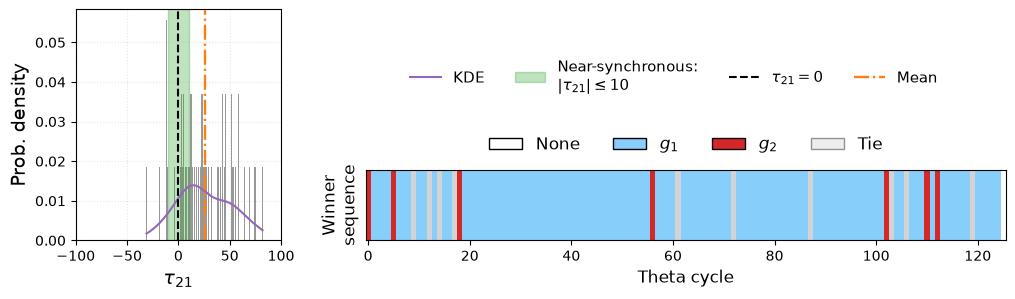

In [15]:
# ------------------------------------------------------------
# Plotting parameters
# ------------------------------------------------------------
fs = 14
lw = 1.5

# ------------------------------------------------------------
# Colormap for the winner sequence
#
# 0 = none
# 1 = g2
# 2 = tie
# 3 = g1
# ------------------------------------------------------------
cmap = ListedColormap([
    "white",       # 0 = none
    "C3",          # 1 = g2
    "lightgray",   # 2 = tie
    "lightskyblue" # 3 = g1
])

norm = BoundaryNorm(
    [-0.5, 0.5, 1.5, 2.5, 3.5],
    cmap.N
)

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------
fig = plt.figure(figsize=(12, 3))
gs = GridSpec(2, 13, height_ratios=[1, 0.5])

# ------------------------------------------------------------
# A: Distribution of temporal lag
#
# tau_21 = t_g2 - t_g1
# Positive values indicate that g1 responds earlier.
# ------------------------------------------------------------
ax = fig.add_subplot(gs[:, :3])

if len(delta_t) > 0:
    x_left, x_right = -100, 100

    bins = np.arange(
        np.floor(delta_t.min()) - 0.5,
        np.ceil(delta_t.max()) + 1.5,
        1
    )

    ax.hist(
        delta_t,
        bins=bins,
        density=True,
        color="C7",
        alpha=0.8
    )

    # Kernel density estimate.
    # A KDE requires at least two data points with non-zero variance.
    if len(delta_t) > 1 and np.std(delta_t) > 0:
        kde = gaussian_kde(delta_t)

        x_kde = np.linspace(
            delta_t.min(),
            delta_t.max(),
            1000
        )

        y_kde = kde(x_kde)

        ax.plot(
            x_kde,
            y_kde,
            color="C4",
            linewidth=lw,
            label="KDE"
        )

    # Near-synchronous responses.
    ax.axvspan(
        -10,
        10,
        alpha=0.3,
        color="C2",
        label=r"Near-synchronous:" + "\n" + r"$|\tau_{21}|\leq10$"
    )

    # Zero temporal lag.
    ax.axvline(
        0,
        linestyle="--",
        color="black",
        linewidth=lw,
        label=r"$\tau_{21}=0$"
    )

    # Mean temporal lag.
    mean_dt = np.mean(delta_t)

    ax.axvline(
        mean_dt,
        color="C1",
        linestyle="-.",
        linewidth=lw + 0.2,
        label="Mean"
    )

    ax.legend(
        ncol=4,
        fontsize=fs - 3,
        frameon=False,
        loc=(1.6, 0.6)
    )

    ax.set_xlim(x_left, x_right)

else:
    # No cycles in which both target modules responded.
    ax.text(
        0.5,
        0.5,
        "No simultaneous responses",
        ha="center",
        va="center",
        transform=ax.transAxes,
        fontsize=fs - 2
    )

ax.grid(linestyle=":", alpha=0.3)
ax.set_xlabel(r"$\tau_{21}$", fontsize=fs)
ax.set_ylabel("Prob. density", fontsize=fs)


# ------------------------------------------------------------
# B: Winner sequence across theta cycles
#
# Plot coding:
# 0 = none
# 1 = g2
# 2 = tie
# 3 = g1
# ------------------------------------------------------------
ax = fig.add_subplot(gs[1, 4:])

plot_sequence = sequence_for_plot(sequence)

ax.imshow(
    plot_sequence.reshape(1, -1),
    aspect="auto",
    interpolation="none",
    origin="upper",
    cmap=cmap,
    norm=norm
)

ax.set_yticks([])
ax.set_yticklabels([])
ax.set_xlabel("Theta cycle", fontsize=fs - 2)
ax.set_ylabel("Winner\nsequence", fontsize=fs - 2)

legend_elements = [
    Patch(
        facecolor="white",
        edgecolor="black",
        label="None"
    ),
    Patch(
        facecolor="lightskyblue",
        edgecolor="black",
        label=r"$g_1$"
    ),
    Patch(
        facecolor="C3",
        edgecolor="black",
        label=r"$g_2$"
    ),
    Patch(
        facecolor="lightgray",
        alpha=0.4,
        edgecolor="black",
        label="Tie"
    )
]

ax.legend(
    handles=legend_elements,
    ncol=4,
    frameon=False,
    fontsize=fs - 2,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.7)
)